# LSTM Train Model

## Base Initialization

### Global Parameters

In [103]:
stock_code = "GAS"
output_range_scale = 2

In [104]:
output_column = "close"

In [105]:
stock_code = str.lower(stock_code)

### Install libraries

In [106]:
# !pip install -r requirements.txt

### Import libraries

In [ ]:
import os
import sys
import random
import numpy as np
import torch

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from data_preprocessor.data_preprocessor import DataPreprocessor
from dtos.model_dtos.model_config_dto import ModelConfigDto
from logger.logger import Logger, LogType
from model.lstm_model import LSTM_Model
from train_test_creator.train_test_creator import TrainTestCreator
from web_scraper.trading_view_scraper import TradingViewScraper as WebScraper
from utils.constants import *
from utils.enums import *
from utils.utils import plot_model_result

os.environ["WANDB_DISABLE_SYMLINKS"] = "true"

In [108]:
SEED = RANDOM_SEED

# Apply globally
random.seed(SEED)
np.random.seed(SEED)

In [109]:
# train_window_size = DEFAULT_TRAIN_WINDOW_SIZE
# validation_window_size = DEFAULT_VALIDATION_WINDOW_SIZE
# test_window_size = DEFAULT_TEST_WINDOW_SIZE

train_window_size = 300
validation_window_size = 30
test_window_size = 30

print(f"Train window size: {train_window_size}")
print(f"Validation window size: {validation_window_size}")
print(f"Test window size: {test_window_size}")

Train window size: 300
Validation window size: 30
Test window size: 30


### Log Metadata

In [110]:
my_logger = Logger(
    file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/{stock_code}_lstm_train_log"
)

In [111]:
my_logger.log_info(
    f"\nTRAIN MODEL FOR STOCK: '{stock_code}' - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)

### Load Dataframe

In [112]:
my_train_test_creator = TrainTestCreator(logger=my_logger)

In [113]:
dataframe = my_train_test_creator.load_dataframe(
    stock_code=stock_code, file_path=f"../../unified_dataframe/unified_{stock_code}.csv"
)
dataframe

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,2013-03-06,4.707945,42.573445,318.035806,275.767367,9.470968,428.666774,40.638065,31.087742,1423.448966,...,-0.037691,0.044115,1220.608792,964.909607,0.144175,0.147936,-0.003761,69.547974,522.980011,-7875.073746
1,2013-03-07,4.710027,42.585916,324.596774,275.848142,9.706129,428.922903,41.177742,31.329032,1423.865911,...,0.006026,0.045669,1212.631110,964.909607,0.140278,0.146404,-0.006126,45.861928,454.820285,-25492.795995
2,2013-03-08,4.712110,42.598386,331.157742,275.928918,9.941290,429.179032,41.717419,31.570323,1424.282855,...,-0.031238,0.021012,1212.631110,964.909607,0.135737,0.144271,-0.008534,-34.331403,384.941472,-14313.561330
3,2013-03-11,4.718356,42.635797,350.840645,276.171244,10.646774,429.947419,43.336452,32.294194,1425.533689,...,-0.087321,0.025443,1212.631110,964.909607,0.130898,0.141596,-0.010698,-64.185869,320.780424,-8878.216392
4,2013-03-12,4.720438,42.648267,357.401613,276.252019,10.881935,430.203548,43.876129,32.535484,1425.950634,...,-0.063236,0.059730,1217.949564,964.909607,0.126369,0.138551,-0.012182,-53.492223,267.312903,1734.980337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0.405180,0.028466,4676.758295,839.897191,0.030031,0.022065,0.007966,6608.683126,4585.012125,-162996.860877
3023,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0.454877,0.061912,4885.361903,839.897191,0.034203,0.024492,0.009711,7724.802154,5033.553558,-8951.424861
3024,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0.247208,0.001295,4885.361903,780.896149,0.037826,0.027159,0.010667,6231.077840,5204.628455,-328713.260795
3025,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0.120171,-0.002004,4885.361903,792.464981,0.040591,0.029846,0.010746,5858.265949,5298.005240,-155238.649006


In [114]:
dataframe.shape

(3027, 356)

## Find output range

In [115]:
dataframe.close.min(), dataframe.close.max()

(15.7183, 95.4676)

In [116]:
if output_range_scale <= 1:
    output_range_scale = 1.5 # Default value

output_range = (0, dataframe.close.max() * output_range_scale)
output_range

(0, 190.9352)

## Create train test set

In [117]:
train_test_set = my_train_test_creator.create_train_test_set(
    dataframe=dataframe,
    output_column=output_column,
    output_range=output_range,
    stock_code=stock_code,
    train_window_size=train_window_size,
    validation_window_size=validation_window_size,
    test_window_size=test_window_size,
)

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e+02, tolerance: 9.502e+01
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.447e+02, tolerance: 9.502e+01
  model = cd_fast.enet_coordinate_descent(


Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...
🔍 Dropped 26 highly correlated features (|r| >= 0.85):
['close_bb_lower_20', 'close_bb_middle_20', 'close_bb_upper_20', 'close_ema_12', 'close_ema_26', 'close_lwma_12', 'close_lwma_26', 'close_lwma_50', 'close_sma_50', 'close_wma_100', 'close_wma_14', 'close_wma_21', 'close_wma_50', 'close_wma_7', 'kc_lower_20', 'kc_middle_20', 'kc_upper_20', 'low', 'macd_signal_9', 'open', 'roc_9', 'starc_lower_20', 'starc_middle_20', 'starc_upper_20', 'tsi_13_7_signal_7', 'vn_index_close']
✅ Kept 14 features after pruning correlation redundancy.


In [118]:
print(f"Number of training samples: {train_test_set.get_number_of_train_windows()}")

Number of training samples: 79


In [119]:
train_test_set.get_train_window(0)

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.548284,0.000000,0.000000,0.139742,0.000000,0.542525,0.000000,0.000000,0.005678,0.173744,...,0.233857,0.000875,0.467761,0.578960,0.593050,0.304170,0.443745,0.486007,0.447933,0.109142
1,0.548388,0.000184,0.008390,0.139831,0.003334,0.542947,0.001449,0.000781,0.005779,0.179202,...,0.233961,0.000000,0.467761,0.571400,0.590011,0.279650,0.442942,0.482295,0.432703,0.108428
2,0.548493,0.000368,0.016781,0.139921,0.006668,0.543370,0.002899,0.001562,0.005880,0.184661,...,0.232312,0.000000,0.467761,0.562588,0.585776,0.254679,0.440227,0.478488,0.442367,0.108428
3,0.548808,0.000919,0.041952,0.140190,0.016671,0.544638,0.007247,0.003905,0.006182,0.201036,...,0.232609,0.000000,0.467761,0.553199,0.580468,0.232236,0.439216,0.474994,0.447066,0.108428
4,0.548913,0.001103,0.050342,0.140280,0.020005,0.545061,0.008696,0.004687,0.006283,0.206494,...,0.234901,0.000583,0.467761,0.544412,0.574424,0.216856,0.439578,0.472081,0.456240,0.108904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,0.587058,0.100542,0.561528,0.188835,0.330876,0.186568,0.078574,0.193460,0.060900,0.133175,...,0.272161,0.191529,0.621541,0.844033,0.819380,0.538252,0.439554,0.475097,0.417253,0.319210
356,0.587192,0.100725,0.559799,0.188925,0.329236,0.185633,0.078544,0.192101,0.061001,0.133133,...,0.267846,0.191529,0.607164,0.846743,0.827402,0.510822,0.434882,0.471090,0.385398,0.314103
357,0.587594,0.101277,0.554610,0.189194,0.324316,0.182828,0.078456,0.188022,0.061304,0.133006,...,0.266941,0.191529,0.607164,0.846812,0.833834,0.477585,0.430685,0.466692,0.392450,0.314103
358,0.587728,0.101461,0.552881,0.189284,0.322676,0.181894,0.078426,0.186662,0.061405,0.132964,...,0.246580,0.183615,0.607164,0.846790,0.838975,0.450608,0.419027,0.460244,0.382456,0.306442


In [120]:
train_test_set.get_train_window().shape

(360, 328)

In [121]:
train_test_set.get_test_set()

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,2024-02-06,6.289011,92.317287,692.758621,837.931034,63.793103,517.241379,247.586207,231.724138,2751.724138,...,0.074534,3493.236998,1114.539514,0.045062,0.046759,-0.001696,204.226740,190.451195,40032.764026,68.887
1,2024-02-07,6.277363,92.329757,686.551724,827.586207,62.758621,503.448276,245.517241,230.344828,2710.344828,...,0.103196,3493.236998,1114.539514,0.044582,0.046323,-0.001741,177.882924,188.655728,-10147.774416,68.887
2,2024-02-15,6.184176,92.429519,636.896552,744.827586,54.482759,393.103448,228.965517,219.310345,2379.310345,...,0.046010,3493.236998,1114.539514,0.044084,0.045876,-0.001791,240.462638,196.056715,28694.524075,68.887
3,2024-02-16,6.172527,92.441989,630.689655,734.482759,53.448276,379.310345,226.896552,217.931034,2337.931034,...,0.022599,3534.768217,1114.539514,0.043941,0.045489,-0.001547,620.065916,256.629458,160058.836929,69.706
4,2024-04-19,5.925165,93.227615,701.946333,720.000000,61.333333,286.666667,287.000000,250.000000,2795.000000,...,-0.029731,3534.768217,1091.259315,0.043922,0.045175,-0.001253,217.502723,251.039925,32729.744875,68.250
5,2024-02-19,6.137582,92.479400,612.068966,703.448276,50.344828,337.931034,220.689655,213.793103,2213.793103,...,0.017572,3737.428261,1091.259315,0.045425,0.045225,0.000199,1852.295755,479.790758,340928.147449,72.163
6,2024-02-20,6.125934,92.491870,605.862069,693.103448,49.310345,324.137931,218.620690,212.413793,2172.413793,...,0.067701,3737.428261,1081.626509,0.046909,0.045562,0.001347,2120.343385,714.155419,63661.546483,71.526
7,2024-02-21,6.114286,92.504340,599.655172,682.758621,48.275862,310.344828,216.551724,211.034483,2131.034483,...,0.061943,3694.633281,1081.626509,0.048406,0.046131,0.002275,1613.820872,842.679055,-179103.288474,70.707
8,2024-04-25,6.008901,93.302437,717.248333,720.000000,63.333333,266.666667,245.000000,250.000000,2825.000000,...,-0.008019,3694.633281,1030.120485,0.049520,0.046809,0.002711,1281.548828,905.374737,-233745.272016,67.340
9,2024-02-22,6.102637,92.516811,593.448276,672.413793,47.241379,296.551724,214.482759,209.655172,2089.655172,...,0.062772,3889.350441,1030.120485,0.050646,0.047576,0.003070,1522.720068,993.566927,-20855.346842,70.889


In [122]:
train_test_set.get_test_set().shape

(30, 356)

## Setup model

In [ ]:
lstm_model_config = ModelConfigDto(
    # Metadata
    entity=WANDB_ENTITY_NAME,
    project=WANDB_PROJECT_NAME,
    architecture=ModelAchitectureType.LSTM,
    stock_code=stock_code,
    # Windowing
    window_type=WindowType.SLIDING,
    train_window_size=train_window_size,
    validation_window_size=validation_window_size,
    test_window_size=test_window_size,
    # Training
    epochs=400,
    learning_rate=0.001,
    batch_size=64,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    # Data & metrics
    scaler_type=ScalerType.MINMAX,
    metric=MetricType.MAPE,
    # Output scale
    output_range_scale=output_range_scale,
    output_range=output_range,
    # Reproducibility & runtime
    seed=RANDOM_SEED,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)
lstm_model_config.format_config()

{
    "entity": "trung-lyduc18",
    "project": "master_thesis",
    "architecture": "lstm",
    "stock_code": "gas",
    "window_type": "sliding",
    "train_window_size": 300,
    "validation_window_size": 30,
    "test_window_size": 30,
    "epochs": 400,
    "learning_rate": 0.002,
    "batch_size": 128,
    "optimizer": "adam",
    "loss_fn": "mse",
    "scaler_type": "minmax",
    "metric": "mape",
    "device": "cuda",
    "output_range_scale": 2,
    "output_range": [
        0,
        190.9352
    ],
    "seed": 42,
    "lr_scheduler": null
}


In [124]:
my_lstm_model = LSTM_Model(
    logger=my_logger, train_test_set=train_test_set, model_config=lstm_model_config
)

PyTorch version: 2.5.1+cu121


## Start training the model

In [125]:
model_output_dto = my_lstm_model.train()

Training on cuda for 400 epochs...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\ADMIN\_netrc


Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch [1/400] - Train: 0.09793001 | Val: 0.08258261 | LR: 1.999969e-03


Epoch 2:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 200:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch [200/400] - Train: 0.00032433 | Val: 0.00029333 | LR: 1.000000e-03


Epoch 201:   0%|          | 0/1 [00:00<?, ?it/s]

Early stopping at epoch 201 (best val loss: 0.000288)
Training completed in 15.69s | Test MAPE: 2.40%


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇█████
learning_rate,█████████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁
test_mape,▁
train_loss,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,200
learning_rate,0.001
test_mape,2.4005
train_loss,0.00032
val_loss,0.00029


In [126]:
model_output_dto.mape

2.4005041122436523

In [127]:
model_output_dto.y_pred_denorm

array([72.283264, 72.02095 , 72.44468 , 71.896164, 72.75078 , 72.3962  ,
       72.28788 , 72.33359 , 72.4676  , 72.76686 , 71.43831 , 71.95109 ,
       71.09922 , 72.54207 , 71.66355 , 71.8789  , 71.79455 , 72.57439 ,
       72.106285, 71.71592 , 72.21075 , 72.64886 , 73.229416, 72.641624,
       73.18092 , 72.65926 , 72.27088 , 72.1798  , 72.31749 , 72.95551 ],
      dtype=float32)

In [128]:
model_output_dto.y_true

array([68.887, 68.887, 68.887, 69.706, 68.25 , 72.163, 71.526, 70.707,
       67.34 , 70.889, 69.524, 69.342, 70.616, 70.98 , 70.434, 70.616,
       70.798, 71.89 , 72.982, 73.164, 72.345, 70.798, 70.889, 71.89 ,
       73.71 , 74.893, 70.889, 72.982, 72.527, 73.71 ], dtype=float32)

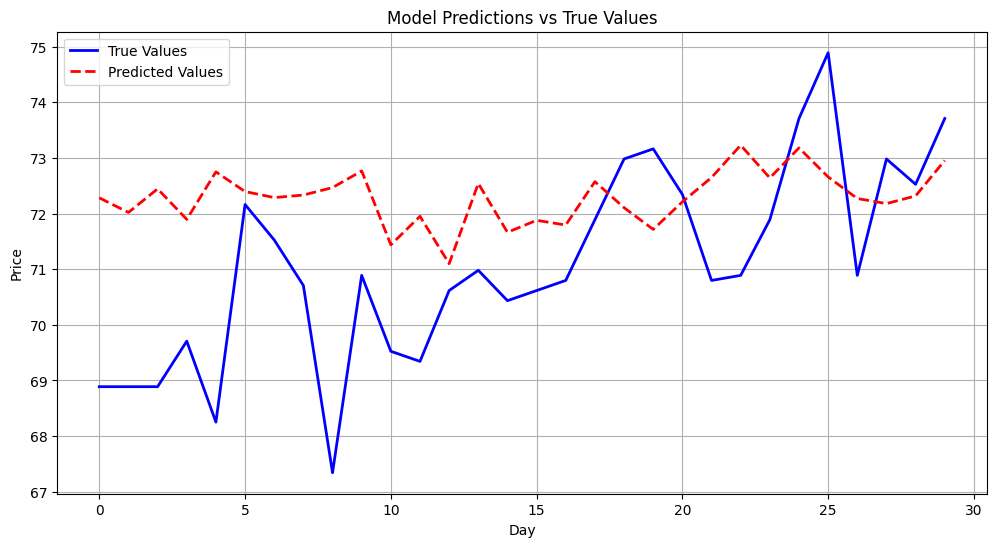

In [129]:
plot_model_result(model_output_dto=model_output_dto)